In [2]:
import xgboost
from xgboost import XGBClassifier
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, cohen_kappa_score,
    recall_score, precision_score, roc_auc_score,
    matthews_corrcoef
)

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM, Bidirectional, Conv1D, MaxPooling1D, Flatten, Input
from tensorflow.keras.callbacks import EarlyStopping

# -----------------------------
# 1. Load Kaggle breast cancer data
# -----------------------------
data = load_breast_cancer()

# Encode diagnosis: malignant = 0, benign = 1
data['diagnosis'] = data['diagnosis'].map({'M': 0, 'B': 1})

# Drop unused columns
X = data.drop(columns=['id', 'diagnosis', 'Unnamed: 32'], errors='ignore').values
y = data['diagnosis'].values

# -----------------------------
# 2. Train / val / test split
# -----------------------------
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=42
)
# 60% train, 20% val, 20% test

# -----------------------------
# 3. Scale data where needed
# -----------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# For sequence/deep models: reshape to (samples, timesteps, channels)
n_features = X_train_scaled.shape[1]
X_train_seq = X_train_scaled.reshape((X_train_scaled.shape[0], n_features, 1))
X_val_seq   = X_val_scaled.reshape((X_val_scaled.shape[0], n_features, 1))
X_test_seq  = X_test_scaled.reshape((X_test_scaled.shape[0], n_features, 1))

# -----------------------------
# 4. Metric helpers
# -----------------------------
# IMPORTANT: malignant = 0 is treated as the positive class
POS_LABEL = 0

def specificity_score(y_true, y_pred):
    # Specificity = true negative rate
    # Since benign = 1 is the negative class,
    # specificity is recall for the benign class.
    return recall_score(y_true, y_pred, pos_label=1)

def collect_metrics(y_true, y_pred, y_score):
    return {
        "Test_accuracy": accuracy_score(y_true, y_pred),
        "F1_score": f1_score(y_true, y_pred, pos_label=POS_LABEL),
        "Kappa": cohen_kappa_score(y_true, y_pred),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred, pos_label=POS_LABEL),
        "Specificity": specificity_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, pos_label=POS_LABEL),
        "AUC": roc_auc_score(y_true, y_score),
    }

def evaluate_sklearn_model(name, model, Xtr, ytr, Xv, yv, Xte, yte):
    model.fit(Xtr, ytr)

    y_train_pred = model.predict(Xtr)
    y_val_pred = model.predict(Xv)
    y_test_pred = model.predict(Xte)

    if hasattr(model, "predict_proba"):
        y_test_score = model.predict_proba(Xte)[:, 1]
    else:
        y_test_score = model.decision_function(Xte)

    row = {
        "Model": name,
        "Train_accuracy": accuracy_score(ytr, y_train_pred),
        "Val_accuracy": accuracy_score(yv, y_val_pred),
    }
    row.update(collect_metrics(yte, y_test_pred, y_test_score))
    return row

def evaluate_keras_model(name, model, Xtr, ytr, Xv, yv, Xte, yte, epochs=50, batch_size=32):
    early_stop = EarlyStopping(
        monitor="val_loss", patience=8, restore_best_weights=True
    )

    history = model.fit(
        Xtr, ytr,
        validation_data=(Xv, yv),
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
        callbacks=[early_stop]
    )

    # Accuracies
    train_loss, train_acc, *rest1 = model.evaluate(Xtr, ytr, verbose=0)
    val_loss, val_acc, *rest2 = model.evaluate(Xv, yv, verbose=0)

    # Predictions
    y_test_prob = model.predict(Xte, verbose=0).ravel()
    y_test_pred = (y_test_prob >= 0.5).astype(int)

    row = {
        "Model": name,
        "Train_accuracy": train_acc,
        "Val_accuracy": val_acc,
    }
    row.update(collect_metrics(yte, y_test_pred, y_test_prob))
    return row

# -----------------------------
# 5. Classical ML models
# -----------------------------
results = []

# SVM
svm_model = SVC(kernel="rbf", probability=True, random_state=42)
results.append(
    evaluate_sklearn_model(
        "SVM", svm_model,
        X_train_scaled, y_train,
        X_val_scaled, y_val,
        X_test_scaled, y_test
    )
)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
results.append(
    evaluate_sklearn_model(
        "Random Forest", rf_model,
        X_train, y_train,
        X_val, y_val,
        X_test, y_test
    )
)

# AdaBoost
ada_model = AdaBoostClassifier(n_estimators=100, random_state=42)
results.append(
    evaluate_sklearn_model(
        "AdaBoost", ada_model,
        X_train, y_train,
        X_val, y_val,
        X_test, y_test
    )
)

# KNN
knn_model = KNeighborsClassifier(n_neighbors=7, weights="distance")
results.append(
    evaluate_sklearn_model(
        "KNN", knn_model,
        X_train_scaled, y_train,
        X_val_scaled, y_val,
        X_test_scaled, y_test
    )
)

# XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)
results.append(
    evaluate_sklearn_model(
        "XGBoost", xgb_model,
        X_train, y_train,
        X_val, y_val,
        X_test, y_test
    )
)

# Bagging
bag_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
results.append(
    evaluate_sklearn_model(
        "Bagging", bag_model,
        X_train, y_train,
        X_val, y_val,
        X_test, y_test
    )
)

# Naive Bayes
gnb_model = GaussianNB()
results.append(
    evaluate_sklearn_model(
        "Naive Bayes", gnb_model,
        X_train_scaled, y_train,
        X_val_scaled, y_val,
        X_test_scaled, y_test
    )
)

# -----------------------------
# 6. Deep learning models
# -----------------------------
tf.keras.utils.set_random_seed(42)

# ANN
ann_model = Sequential([
    Input(shape=(n_features,)),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])
ann_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)
results.append(
    evaluate_keras_model(
        "ANN", ann_model,
        X_train_scaled, y_train,
        X_val_scaled, y_val,
        X_test_scaled, y_test,
        epochs=60
    )
)

# LSTM
lstm_model = Sequential([
    Input(shape=(n_features, 1)),
    LSTM(32),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])
lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)
results.append(
    evaluate_keras_model(
        "LSTM", lstm_model,
        X_train_seq, y_train,
        X_val_seq, y_val,
        X_test_seq, y_test,
        epochs=60
    )
)

# Bi-LSTM
bilstm_model = Sequential([
    Input(shape=(n_features, 1)),
    Bidirectional(LSTM(32)),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])
bilstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)
results.append(
    evaluate_keras_model(
        "Bi-LSTM", bilstm_model,
        X_train_seq, y_train,
        X_val_seq, y_val,
        X_test_seq, y_test,
        epochs=60
    )
)

# 1D-CNN
cnn1d_model = Sequential([
    Input(shape=(n_features, 1)),
    Conv1D(filters=32, kernel_size=3, activation="relu"),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])
cnn1d_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)
results.append(
    evaluate_keras_model(
        "1D-CNN", cnn1d_model,
        X_train_seq, y_train,
        X_val_seq, y_val,
        X_test_seq, y_test,
        epochs=60
    )
)

# -----------------------------
# 7. Final results table
# -----------------------------
results_df = pd.DataFrame(results)

metric_cols = [
    "Train_accuracy", "Val_accuracy", "Test_accuracy",
    "F1_score", "Kappa", "MCC",
    "Recall", "Specificity", "Precision", "AUC"
]

results_df[metric_cols] = results_df[metric_cols].round(4)

print(results_df.to_string(index=False))
results_df.to_clipboard(index=False)

        Model  Train_accuracy  Val_accuracy  Test_accuracy  F1_score  Kappa    MCC  Recall  Specificity  Precision    AUC
          SVM          0.9824        0.9825         0.9737    0.9639 0.9432 0.9433  0.9524       0.9861     0.9756 0.9944
Random Forest          1.0000        0.9561         0.9474    0.9286 0.8869 0.8869  0.9286       0.9583     0.9286 0.9907
     AdaBoost          1.0000        0.9737         0.9474    0.9268 0.8858 0.8864  0.9048       0.9722     0.9500 0.9845
          KNN          1.0000        0.9561         0.9825    0.9756 0.9619 0.9626  0.9524       1.0000     1.0000 0.9921
      XGBoost          1.0000        0.9649         0.9474    0.9286 0.8869 0.8869  0.9286       0.9583     0.9286 0.9914
      Bagging          1.0000        0.9386         0.9386    0.9176 0.8687 0.8689  0.9286       0.9444     0.9070 0.9934
  Naive Bayes          0.9413        0.9298         0.9386    0.9157 0.8674 0.8676  0.9048       0.9583     0.9268 0.9878
          ANN          0

In [9]:
from sklearn.metrics import (
    accuracy_score, f1_score, cohen_kappa_score,
    recall_score, precision_score, roc_auc_score,
    matthews_corrcoef
)

# malignant = 0 is treated as the positive class
POS_LABEL = 0
NEG_LABEL = 1

def specificity_score(y_true, y_pred):
    return recall_score(y_true, y_pred, pos_label=NEG_LABEL)

def collect_metrics(y_true, y_pred, y_score):
    return {
        "Test_accuracy": accuracy_score(y_true, y_pred),
        "F1_score": f1_score(y_true, y_pred, pos_label=POS_LABEL),
        "Kappa": cohen_kappa_score(y_true, y_pred),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred, pos_label=POS_LABEL),
        "Specificity": specificity_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, pos_label=POS_LABEL),
        "AUC": roc_auc_score(y_true, y_score),
    }

metric_cols = [
    "Train_accuracy", "Val_accuracy", "Test_accuracy",
    "F1_score", "Kappa", "MCC",
    "Recall", "Specificity", "Precision", "AUC"
]

results_df[metric_cols] = results_df[metric_cols].round(4)

print(results_df.to_string(index=False))

        Model  Train_accuracy  Val_accuracy  Test_accuracy  F1_score  Kappa    MCC  Recall  Specificity  Precision    AUC
          SVM          0.9824        0.9825         0.9737    0.9639 0.9432 0.9433  0.9524       0.9861     0.9756 0.9944
Random Forest          1.0000        0.9561         0.9474    0.9286 0.8869 0.8869  0.9286       0.9583     0.9286 0.9907
     AdaBoost          1.0000        0.9737         0.9474    0.9268 0.8858 0.8864  0.9048       0.9722     0.9500 0.9845
          KNN          1.0000        0.9561         0.9825    0.9756 0.9619 0.9626  0.9524       1.0000     1.0000 0.9921
      XGBoost          1.0000        0.9649         0.9474    0.9286 0.8869 0.8869  0.9286       0.9583     0.9286 0.9914
      Bagging          1.0000        0.9386         0.9386    0.9176 0.8687 0.8689  0.9286       0.9444     0.9070 0.9934
  Naive Bayes          0.9413        0.9298         0.9386    0.9157 0.8674 0.8676  0.9048       0.9583     0.9268 0.9878
          ANN          0

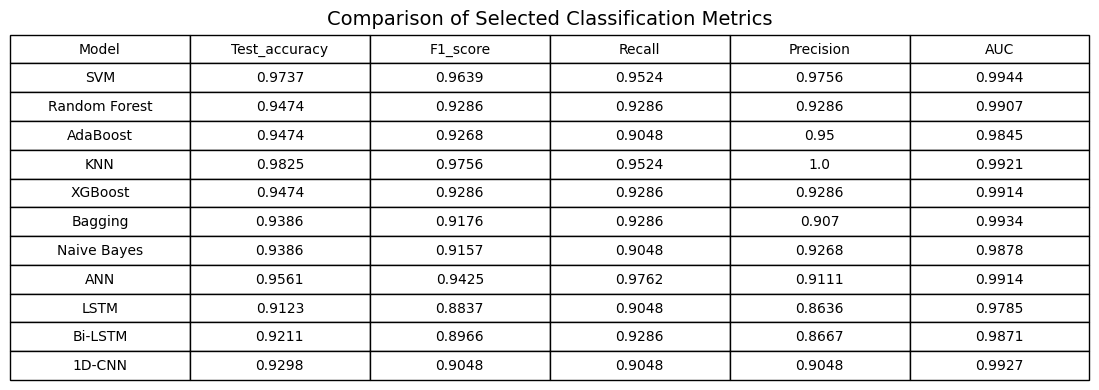

In [11]:
import matplotlib.pyplot as plt

table_df = results_df[[
    "Model", "Test_accuracy", "F1_score", "Recall", "Precision", "AUC"
]].copy()

table_df = table_df.round(4)

fig, ax = plt.subplots(figsize=(11, 4))
ax.axis("off")

tbl = ax.table(
    cellText=table_df.values,
    colLabels=table_df.columns,
    cellLoc="center",
    loc="center"
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.6)

plt.title("Comparison of Selected Classification Metrics", fontsize=14, pad=12)
plt.tight_layout()
plt.savefig("results_table.png", dpi=300, bbox_inches="tight")
plt.show()

In [5]:
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, recall_score, precision_score, roc_auc_score

train_loss, train_acc, train_auc = cnn1d_model.evaluate(X_train_seq, y_train, verbose=0)
val_loss, val_acc, val_auc = cnn1d_model.evaluate(X_val_seq, y_val, verbose=0)

y_test_prob = cnn1d_model.predict(X_test_seq, verbose=0).ravel()
y_test_pred = (y_test_prob >= 0.5).astype(int)

test_acc = accuracy_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
kappa = cohen_kappa_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
auc = roc_auc_score(y_test, y_test_prob)

print("Train accuracy:", round(train_acc, 4))
print("Val accuracy:", round(val_acc, 4))
print("Test accuracy:", round(test_acc, 4))
print("F1:", round(f1, 4))
print("Kappa:", round(kappa, 4))
print("Recall:", round(recall, 4))
print("Precision:", round(precision, 4))
print("AUC:", round(auc, 4))

Train accuracy: 0.9912
Val accuracy: 0.9825
Test accuracy: 0.9298
F1: 0.9444
Kappa: 0.8492
Recall: 0.9444
Precision: 0.9444
AUC: 0.9927


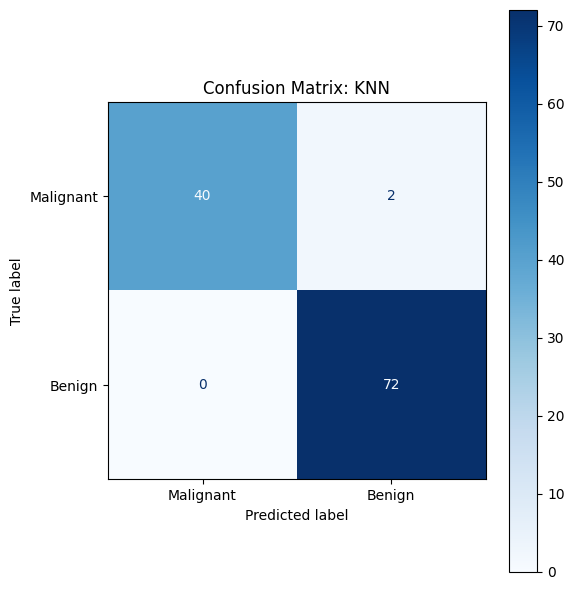

In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Fit best model
best_model = KNeighborsClassifier(n_neighbors=7, weights="distance")
best_model.fit(X_train_scaled, y_train)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test_scaled,
    y_test,
    display_labels=["Malignant", "Benign"],
    cmap="Blues",
    ax=ax
)

ax.set_title("Confusion Matrix: KNN")
plt.tight_layout()
plt.savefig("knn_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

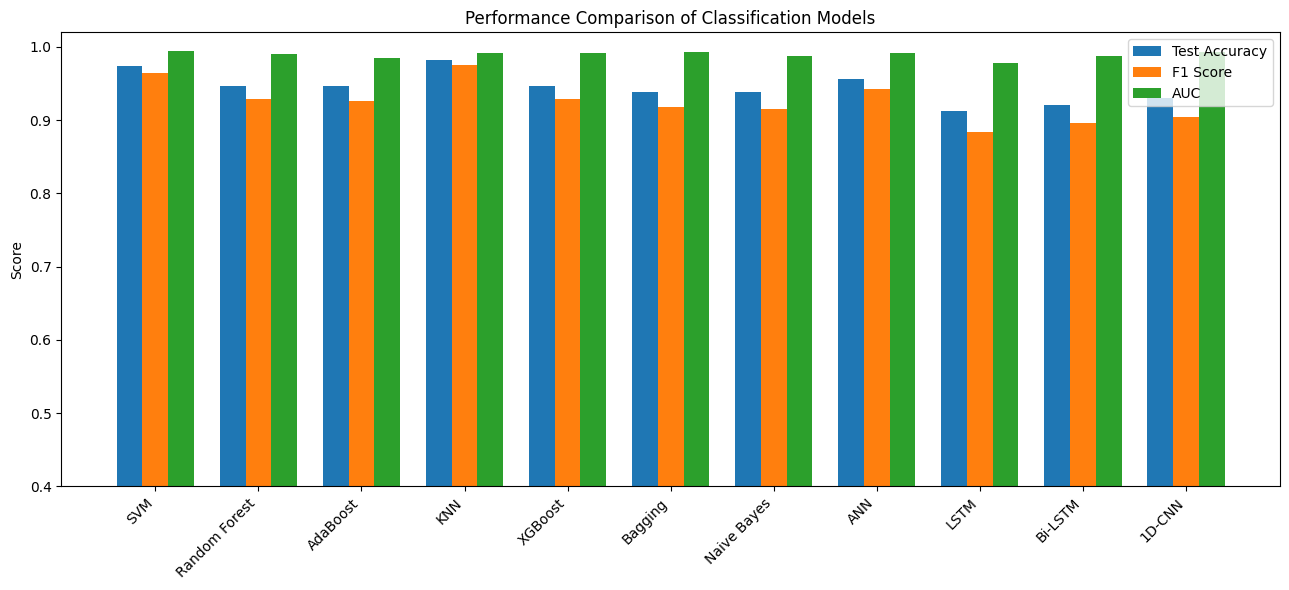

In [14]:
import numpy as np
import matplotlib.pyplot as plt

plot_df = results_df[["Model", "Test_accuracy", "F1_score", "AUC"]].copy()
plot_df = plot_df.round(4)

x = np.arange(len(plot_df))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))

ax.bar(x - width, plot_df["Test_accuracy"], width, label="Test Accuracy")
ax.bar(x, plot_df["F1_score"], width, label="F1 Score")
ax.bar(x + width, plot_df["AUC"], width, label="AUC")

ax.set_xticks(x)
ax.set_xticklabels(plot_df["Model"], rotation=45, ha="right")
ax.set_ylim(0.4, 1.02)
ax.set_ylabel("Score")
ax.set_title("Performance Comparison of Classification Models")
ax.legend()

plt.tight_layout()
plt.savefig("performance_bar_chart.png", dpi=300, bbox_inches="tight")
plt.show()

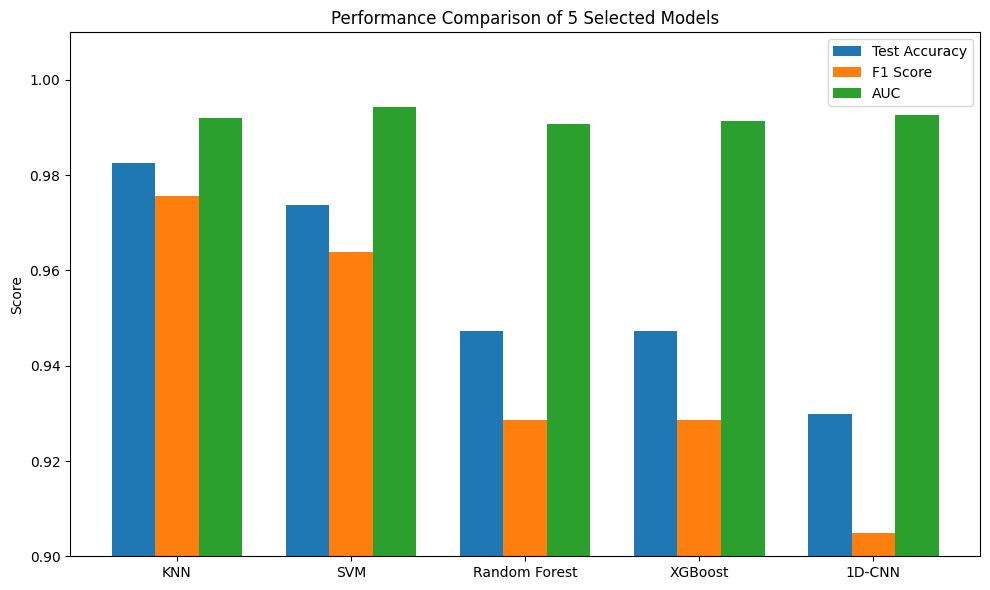

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Keep only these 5 models, in this exact order
selected_models = ["KNN", "SVM", "Random Forest", "XGBoost", "1D-CNN"]

plot_df = results_df[results_df["Model"].isin(selected_models)].copy()
plot_df["Model"] = pd.Categorical(plot_df["Model"], categories=selected_models, ordered=True)
plot_df = plot_df.sort_values("Model")

# Keep only the metrics you want to plot
plot_df = plot_df[["Model", "Test_accuracy", "F1_score", "AUC"]].round(4)

x = np.arange(len(plot_df))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(x - width, plot_df["Test_accuracy"], width, label="Test Accuracy")
ax.bar(x,         plot_df["F1_score"],      width, label="F1 Score")
ax.bar(x + width, plot_df["AUC"],           width, label="AUC")

ax.set_xticks(x)
ax.set_xticklabels(plot_df["Model"], rotation=0)
ax.set_ylim(0.90, 1.01)
ax.set_ylabel("Score")
ax.set_title("Performance Comparison of 5 Selected Models")
ax.legend()

plt.tight_layout()
plt.savefig("selected_5_models_bar_chart.png", dpi=300, bbox_inches="tight")
plt.show()